## Proyecto SPRING 1 - OPTIMIZACIÓN DE ENTREGA DE SUMINITROS DE ARMAMENTOS Y MUNICIÓN

### Realizado por: Carlos Daniel Bedoya y Julián Alzate

### Descripción del Problema:

El Comandante de la Estación de Guardacostas Primaria de Santa Marta, ordena al señor Comandante de Unidad de Reacción Rápida desarrollar operaciones marítimas de guardacostas en el PAG PTO BOLIVAR con el propósito de garantizar el control del mar, evitar el tráfico de sustancias ilícitas, el tráfico de divisas, el tráfico de migrantes irregulares, la pesca ilegal, el contrabando y el hurto en el mar. Para el desarrollo de estas operaciones es necesario gestionar el suministro de armamento (fusiles Galil) y munición calibre 5.56, los cuales serán distribuidos en la Base Alta Guajira, desde donde se abastecerán las unidades encargadas de las operaciones. Estos suministros provienen de dos proveedores, Estos Unidos e Iran. En este contexto, es necesario determinar la ruta más adecuada para transportar los suministros de forma segura y en el menor tiempo posible, ya que la prioridad de la misión es garantizar la disponibilidad oportuna del material en la Base Alta Guajira para dar inicio a las operaciones marítimas. 


### Algoritmo utilizado: Beam Search

Beam Search es un algoritmo de búsqueda heurística que explora un árbol de soluciones, pero limita el número de caminos que mantiene en cada nivel. A diferencia de una búsqueda exhaustiva, que analiza todas las posibilidades, Beam Search conserva únicamente las k mejores opciones (llamadas beam width o ancho del haz) según una función heurística que estima qué tan prometedora es cada alternativa.

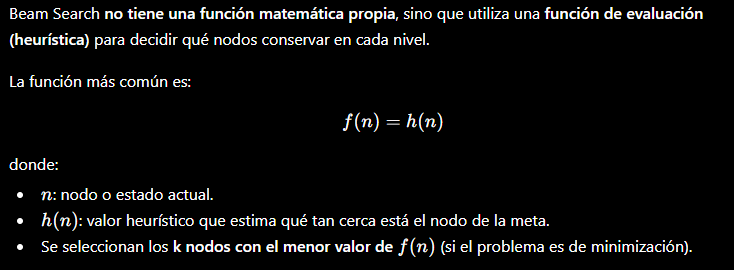


¿Cómo funciona?
Comienza desde el estado inicial.
Genera todos los estados hijos posibles.
Evalúa cada hijo con una función heurística h(n).
Ordena los estados de mejor a peor.
Conserva solo los k mejores y descarta el resto.
Repite el proceso hasta encontrar la solución o no tener más opciones.

Ventaja: Reduce significativamente el tiempo y la memoria respecto a una búsqueda completa en comparación a A*.

Desventaja: Puede descartar el camino correcto si no está entre los mejores en una etapa temprana.

¿Cuándo usar Beam Search?
- Cuando el espacio de búsqueda es muy grande.
- Cuando se necesita una respuesta rápida.
- Cuando una solución "suficientemente buena" es aceptable.

### ¿Por qué Beam Search es la mejor opción para este problema específico?

1. **Naturaleza del contexto operativo (militar/logístico):**
   En operaciones militares, la toma de decisiones debe ser ágil. No se dispone del tiempo ni la certeza de condiciones estables. Se prioriza una respuesta "suficientemente buena" en poco tiempo.

2. **Necesidad de rutas alternativas (contingencia):**
   Este es el punto más determinante. En un escenario real de transporte de armamento y munición, existe riesgo de:
   - Interceptación o ataque en la ruta principal.
   - Fallas logísticas (mal clima, bloqueos, problemas portuarios).
   
   Beam Search mantiene por diseño las *k* mejores rutas en cada nivel de expansión. Esto significa que, ya se cuenta con un conjunto de rutas de respaldo evaluadas y priorizadas. Esto es una ventaja crítica dado que la resiliencia operativa (tener plan B y C) es importante por si surge alguna eventualidad.

3. **Escalabilidad:**
   Si en el futuro se agregan más rutas (nuevos puertos, rutas, proveedores), Beam Search escala mejor porque no necesita mantener en memoria todos los caminos posibles, solo los *k* mejores en cada paso. Esto es clave si el grafo del proyecto crece con más variables (clima, riesgo, tráfico marítimo, etc.).

4. **Se puede variar su enfoque**
   Beam search no tiene un algoritmo o función especifica solo una metodología de analísis de los mejores caminos, por lo que se puede escalar para agregar variables de costos o estimaciones como se hace con A* y otras heuristicas, en caso de que se quiera evaluar otras variables en vez de tiempo, como por ejemplo costos envio, riesgos, etc.

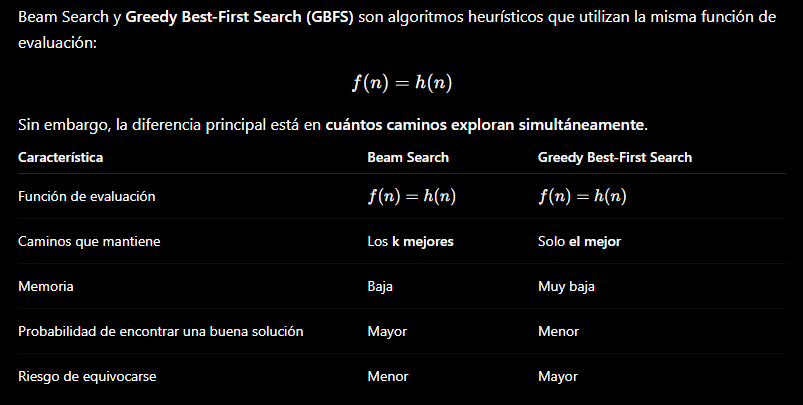


### Grafo:
 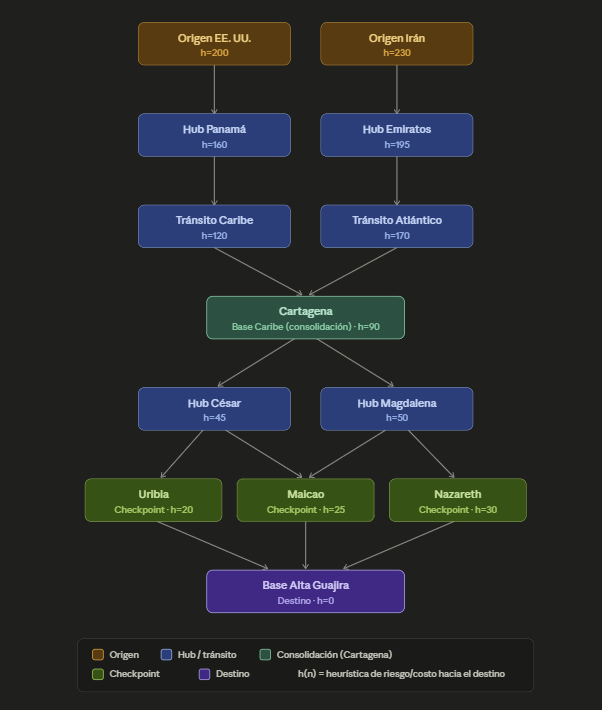

 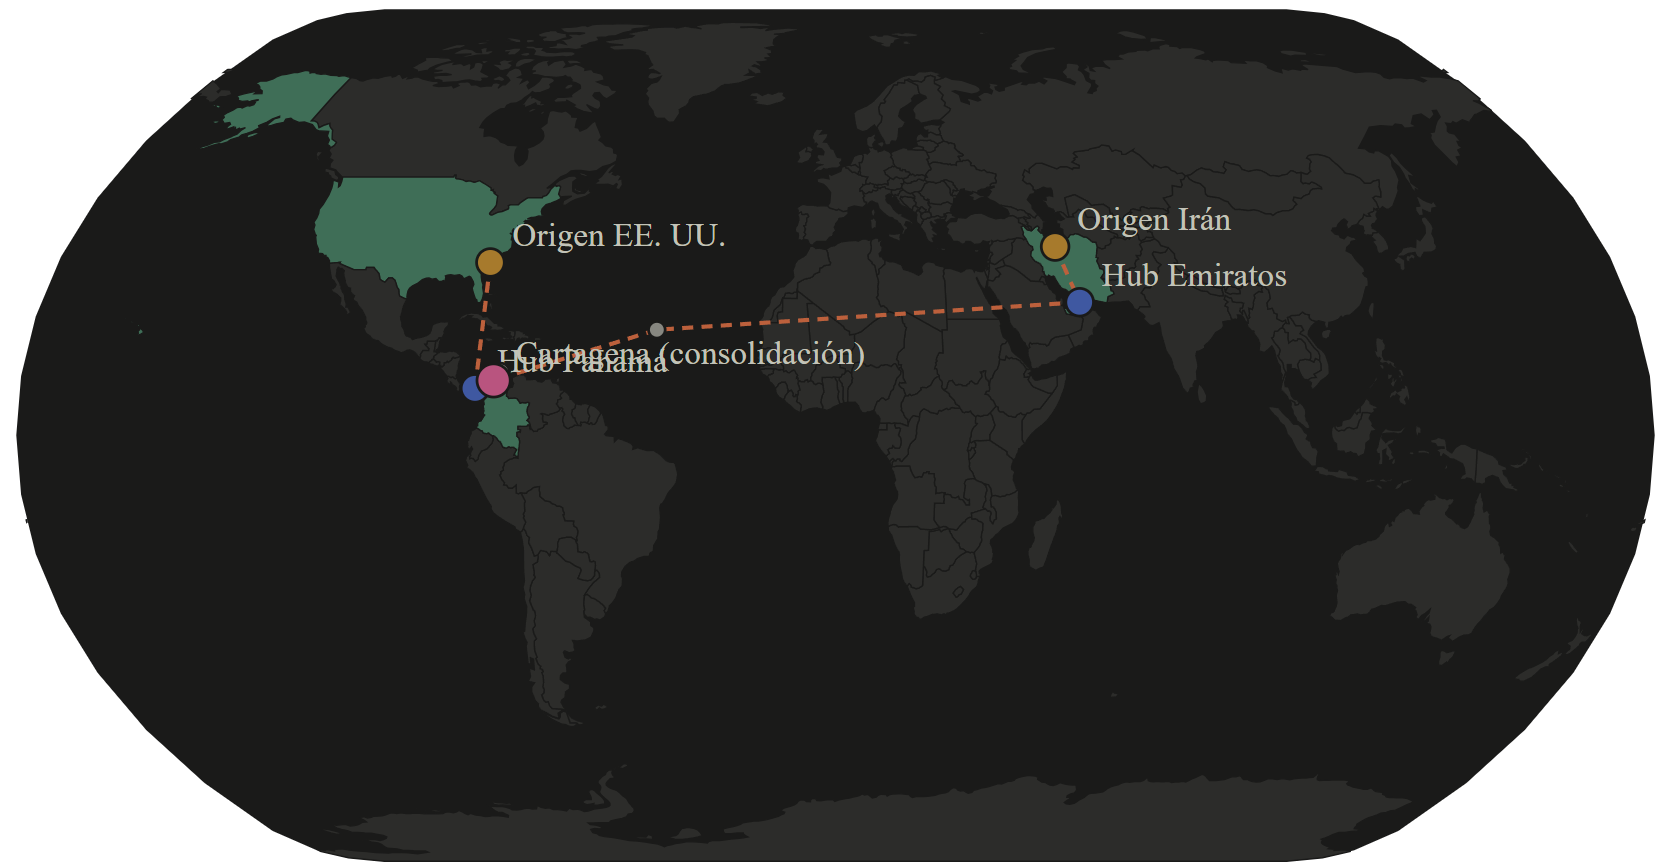

 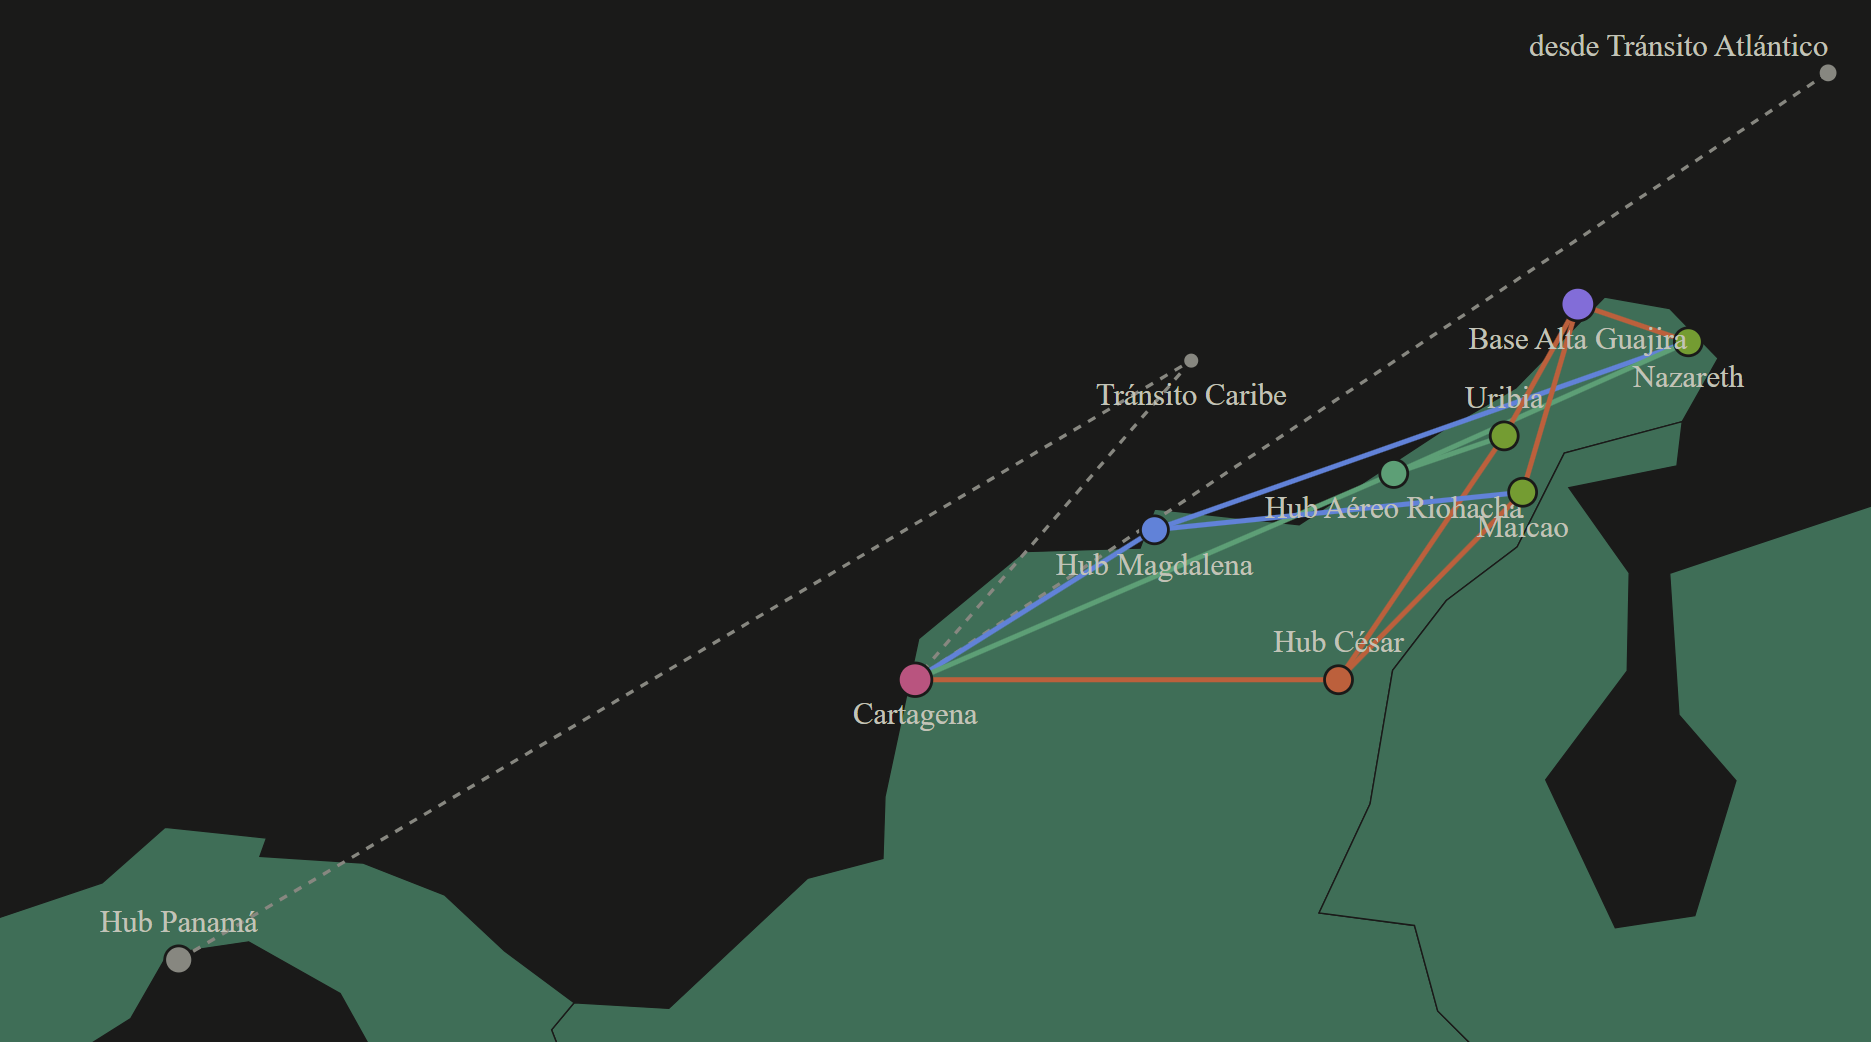

In [ ]:
# La heurística se usa por tiempo en horas, por lo que h = 220 serían 220 horas (≈ 9,1 días)

# --------------------------------------------------------------------
# 1. GRAFO (como diccionario de adyacencias, igual que el ejemplo de A*)
# --------------------------------------------------------------------
red_logistica = {
    "Origen_EEUU":            ["Hub_Panama"],
    "Origen_Iran":             ["Hub_EmiratosArabes"],

    "Hub_Panama":              ["Transito_Caribe"],
    "Hub_EmiratosArabes":      ["Transito_Atlantico"],

    # Ambas rutas CONVERGEN en el nodo de consolidación
    "Transito_Caribe":         ["Base_Caribe_Cartagena"],
    "Transito_Atlantico":      ["Base_Caribe_Cartagena"],

    # Desde Cartagena el árbol se vuelve a ABRIR
    "Base_Caribe_Cartagena":   ["Hub_Cesar", "Hub_Magdalena"],

    "Hub_Cesar":               ["Checkpoint_Uribia", "Checkpoint_Maicao"],
    "Hub_Magdalena":           ["Checkpoint_Maicao", "Checkpoint_Nazareth"],

    # FAN-IN real al destino (3 caminos posibles, no 1 solo)
    "Checkpoint_Uribia":       ["Base_AltaGuajira"],
    "Checkpoint_Maicao":       ["Base_AltaGuajira"],
    "Checkpoint_Nazareth":     ["Base_AltaGuajira"],

    "Base_AltaGuajira":        [],
}

# Heurística h(n): estimación de tiempo (en horas) restante hasta la Base Alta Guajira
heuristica = {
    "Origen_EEUU":            200,
    "Origen_Iran":             230,
    "Hub_Panama":              160,
    "Hub_EmiratosArabes":      195,
    "Transito_Caribe":         120,
    "Transito_Atlantico":      170,
    "Base_Caribe_Cartagena":    90,
    "Hub_Cesar":                45,
    "Hub_Magdalena":            50,
    "Checkpoint_Uribia":        20,
    "Checkpoint_Maicao":        25,
    "Checkpoint_Nazareth":      30,
    "Base_AltaGuajira":          0,
}

# Lista de nodos desde donde comenzará la búsqueda
ORIGENES = ["Origen_EEUU", "Origen_Iran"]
# Nodo objetivo
DESTINO = "Base_AltaGuajira"


# --------------------------------------------------------------------
# 2. BEAM SEARCH
# --------------------------------------------------------------------
def beam_search(origen, destino, beam_width, grafito=True):
    haz = [[origen]]  # El haz comienza únicamente con el nodo origen
    nivel = 0          # Contador del nivel del árbol (reemplaza al atributo "level")

    # Repite mientras exista al menos un camino que no haya llegado al destino
    while not all(c[-1] == destino for c in haz):

        candidatos = []  # Aquí se guardan todos los caminos nuevos generados en esta iteración

        for camino in haz:
            actual = camino[-1]  # Último nodo del camino actual

            if actual == destino:  # Si ya llegó al destino, simplemente lo conserva
                candidatos.append(camino)
                continue

            # Recorre los vecinos del nodo actual usando el diccionario de adyacencias
            for vecino in red_logistica[actual]:
                candidatos.append(camino + [vecino])

        # Ordena todos los caminos según la heurística del último nodo (menor h primero)
        candidatos.sort(key=lambda c: heuristica[c[-1]]) # Para cada camino c, obtenga el valor de la heurística (h) del último nodo del camino. , lambda es una función pequeña para ordenar.
        print("Orden:", candidatos)

        # Beam Search conserva solo los k mejores caminos (poda)
        haz = candidatos[:beam_width]

        if grafito:
            print(f"  Nivel {nivel} -> haz conservado:")
            for c in haz:
                print(f"     h={heuristica[c[-1]]:>3}  {' -> '.join(c)}")
        nivel += 1

    # Selecciona el camino cuya suma de heurísticas sea menor
    mejor = min(haz, key=lambda c: sum(heuristica[n] for n in c))
    costo = sum(heuristica[n] for n in mejor)
    return mejor, costo, haz


# --------------------------------------------------------------------
# 3. EJECUCIÓN
# --------------------------------------------------------------------
for origen in ORIGENES:

    print(f"\n{'='*65}")
    print(f"ORIGEN: {origen}")
    print(f"{'='*65}")

    camino, costo, haz = beam_search(origen, DESTINO, beam_width=1)

    print("\n=== Caminos finales conservados por Beam Search ===")
    for i, ruta in enumerate(haz, start=1):
        costo_ruta = sum(heuristica[n] for n in ruta)
        print(f"{i}. {' -> '.join(ruta)}")
        print(f"   Costo heurístico: {costo_ruta}")

    print("\n>>> Mejor ruta:")
    print(f"{' -> '.join(camino)}")
    print(f"Costo: {costo}")


ORIGEN: Origen_EEUU
Orden: [['Origen_EEUU', 'Hub_Panama']]
  Nivel 0 -> haz conservado:
     h=160  Origen_EEUU -> Hub_Panama
Orden: [['Origen_EEUU', 'Hub_Panama', 'Transito_Caribe']]
  Nivel 1 -> haz conservado:
     h=120  Origen_EEUU -> Hub_Panama -> Transito_Caribe
Orden: [['Origen_EEUU', 'Hub_Panama', 'Transito_Caribe', 'Base_Caribe_Cartagena']]
  Nivel 2 -> haz conservado:
     h= 90  Origen_EEUU -> Hub_Panama -> Transito_Caribe -> Base_Caribe_Cartagena
Orden: [['Origen_EEUU', 'Hub_Panama', 'Transito_Caribe', 'Base_Caribe_Cartagena', 'Hub_Cesar'], ['Origen_EEUU', 'Hub_Panama', 'Transito_Caribe', 'Base_Caribe_Cartagena', 'Hub_Magdalena']]
  Nivel 3 -> haz conservado:
     h= 45  Origen_EEUU -> Hub_Panama -> Transito_Caribe -> Base_Caribe_Cartagena -> Hub_Cesar
Orden: [['Origen_EEUU', 'Hub_Panama', 'Transito_Caribe', 'Base_Caribe_Cartagena', 'Hub_Cesar', 'Checkpoint_Uribia'], ['Origen_EEUU', 'Hub_Panama', 'Transito_Caribe', 'Base_Caribe_Cartagena', 'Hub_Cesar', 'Checkpoint_Maicao'

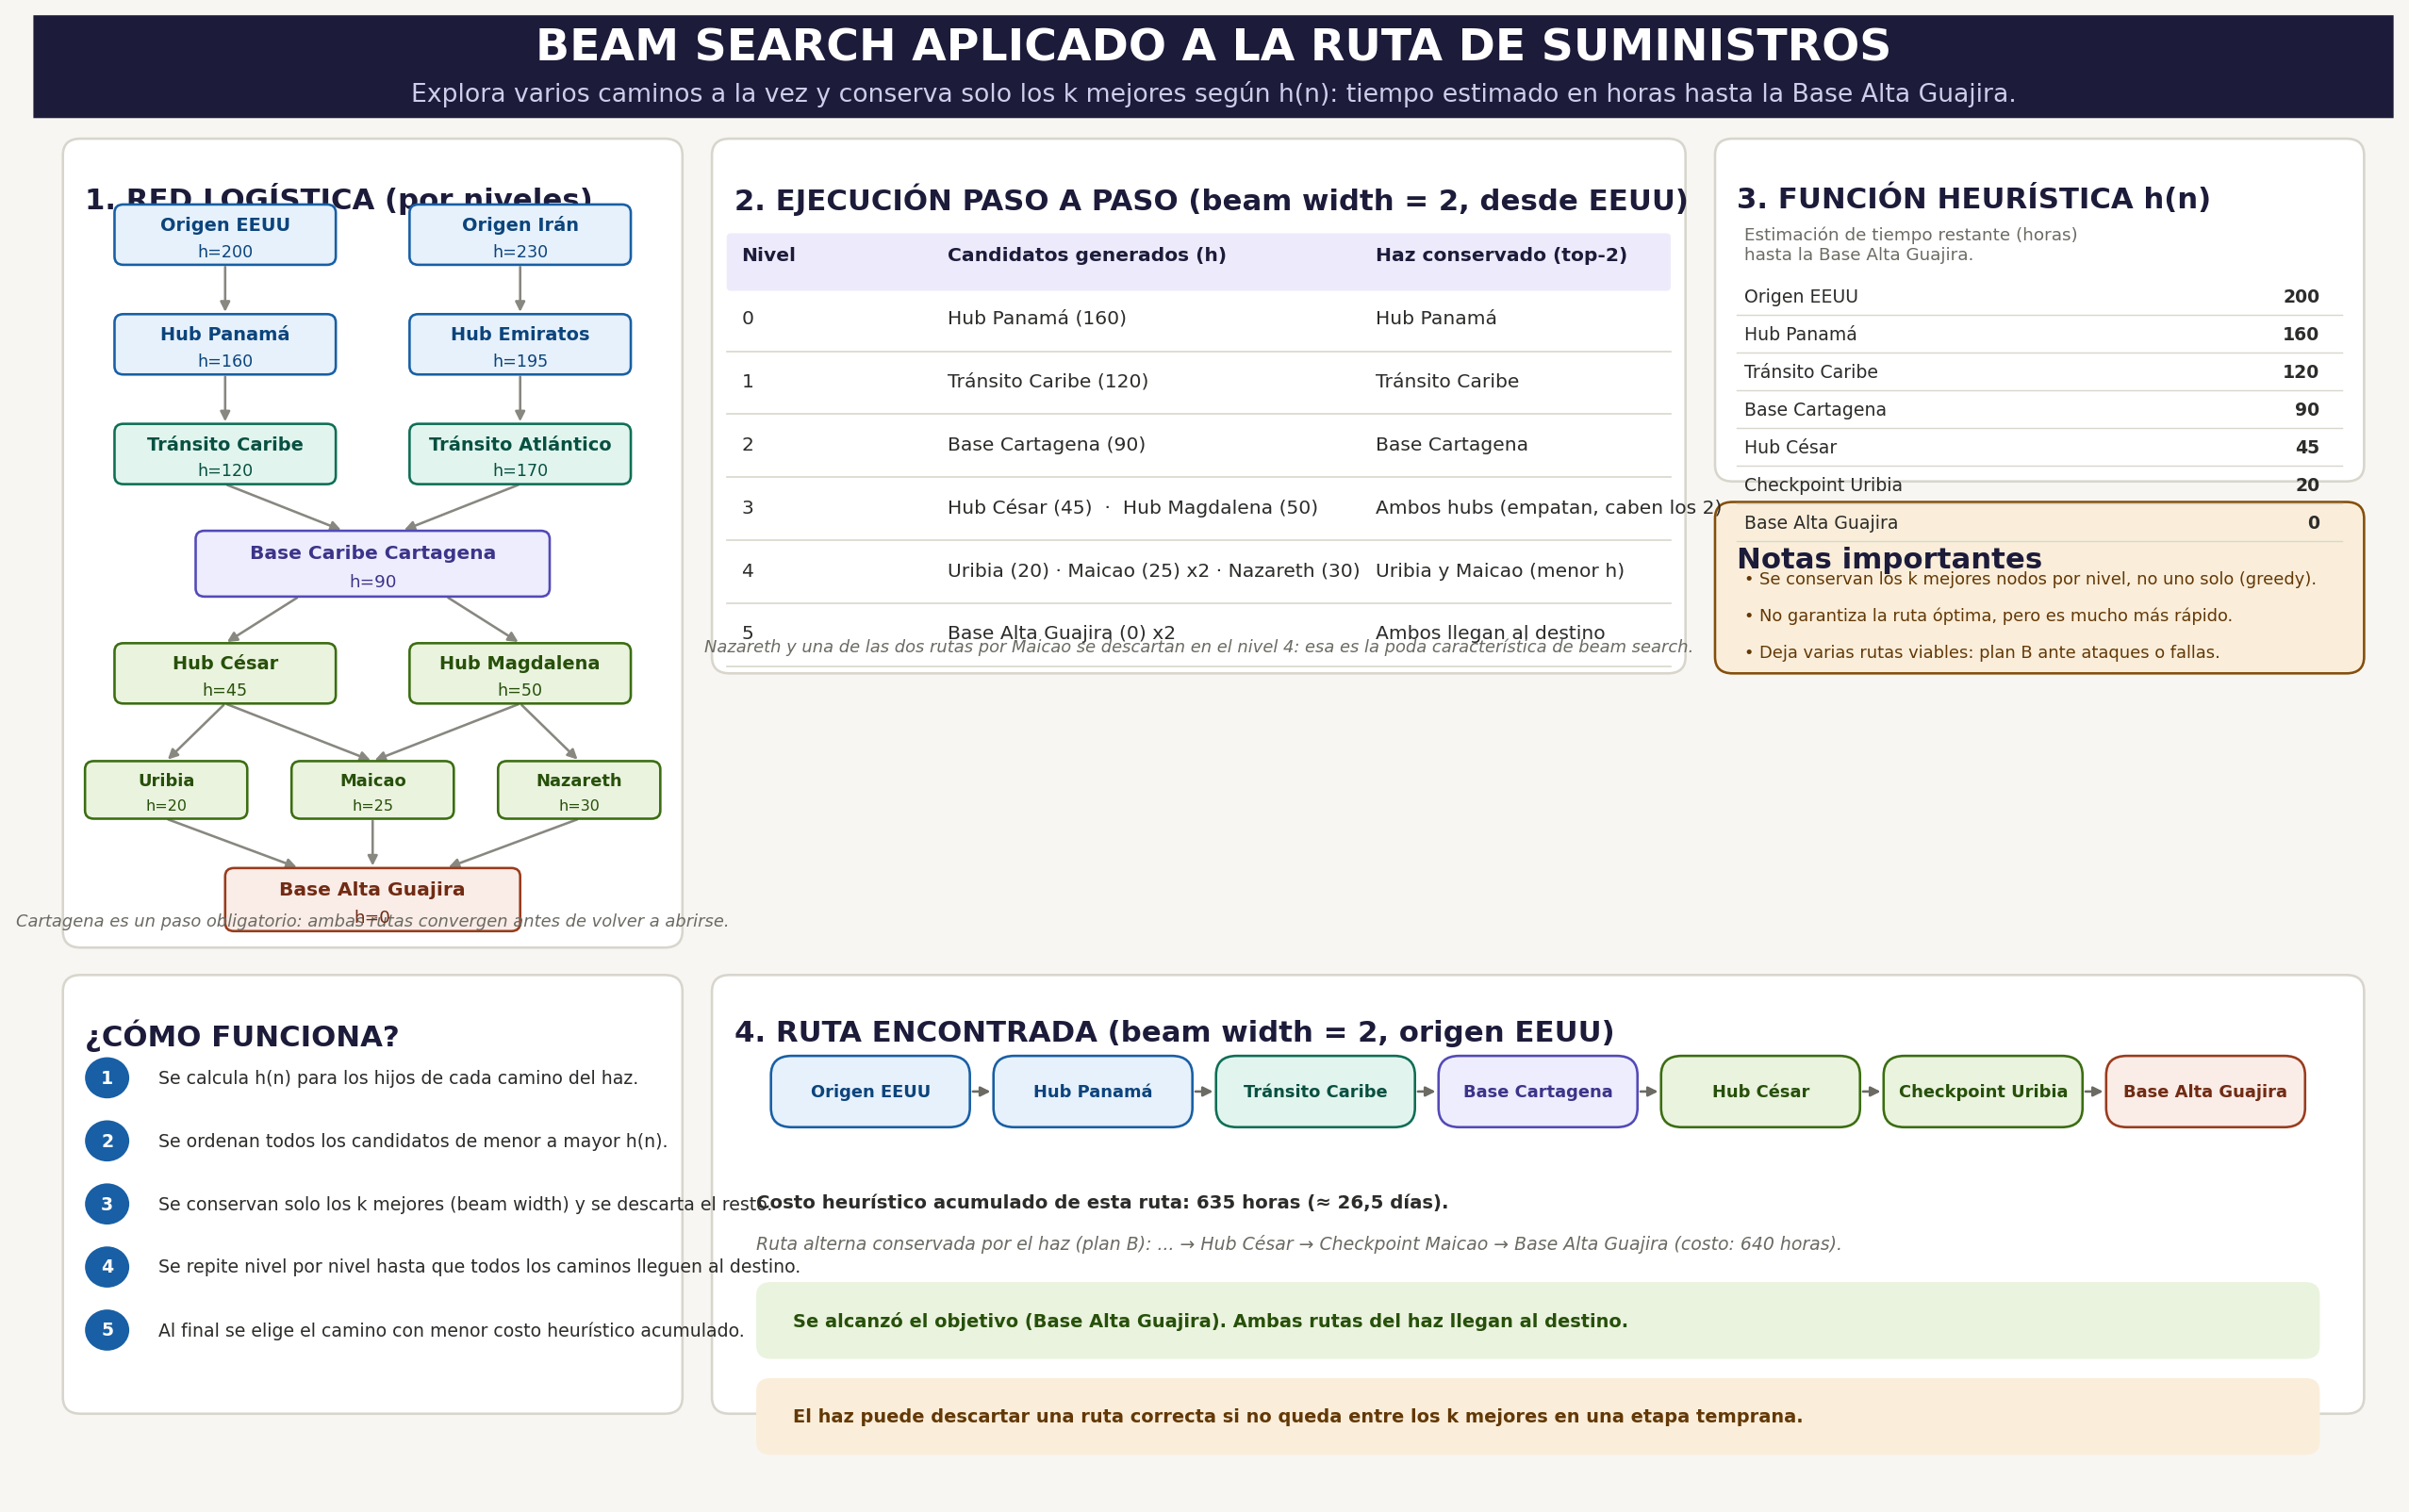